# 5.2. ROI (Region of Interest) Analysis

**Learning Objectives:**
- Understand different brain parcellation schemes and atlases
- Learn how to extract time courses from anatomical regions
- Compare activity across multiple ROIs
- Perform functional connectivity analysis between regions
- Apply ROI-based analysis to group studies
- Understand the advantages and limitations of ROI approaches

**Key Concepts:**
- **Parcellation**: Dividing the brain into discrete anatomical or functional regions
- **Atlas**: A labeled brain template defining ROIs
- **ROI Time Course**: Average activity within a region over time
- **Functional Connectivity**: Statistical dependencies between ROI time courses
- **Seed-based Analysis**: Using one ROI to find connected regions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne
from mne.datasets import sample
from mne.minimum_norm import make_inverse_operator, apply_inverse, apply_inverse_epochs

import pandas as pd
from scipy import stats
from scipy.signal import coherence

import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

### 1. Understanding ROI Analysis

#### What is ROI Analysis?

Instead of analyzing thousands of individual source points (vertices), **ROI analysis** groups sources into anatomically or functionally defined regions.

**Advantages of ROI Analysis:**
- **Reduced dimensionality**: 7,498 sources → 68 regions (for Desikan-Killiany atlas)
- **Anatomical interpretability**: "Primary auditory cortex" vs "vertex 3,421"
- **Increased statistical power**: Averaging reduces noise
- **Facilitates group studies**: ROIs correspond across subjects
- **Enables network analysis**: Study interactions between regions

**Disadvantages:**
- **Loss of spatial detail**: Can't see fine-grained activity patterns
- **Parcellation dependency**: Results depend on how you define ROIs
- **Averaging artifacts**: Can miss focal activations

#### Common Brain Atlases

| Atlas | Regions | Based On | Use Case |
|-------|---------|----------|----------|
| **Desikan-Killiany** | 68 | Gyral anatomy | Standard anatomical parcellation |
| **Destrieux** | 148 | Detailed gyri/sulci | Fine anatomical detail |
| **Schaefer** | 100-1000 | Functional networks | Resting-state networks |
| **AAL** | 116 | MNI template | Group studies, fMRI |
| **HCP-MMP1.0** | 360 | Multi-modal features | High-resolution parcellation |

For this tutorial, we'll use the **Desikan-Killiany** atlas (also called `aparc`), which is included with FreeSurfer.

### 2. Load Sample Data & Preprocessing

In [3]:
repo_root = Path("./").resolve().parents[1]
target_dir = repo_root / "datasets" / "meg_sample"
target_dir.mkdir(parents=True, exist_ok=True)

data_path = sample.data_path(path=str(target_dir), download=True)
subjects_dir = data_path / 'subjects'

# Load MEG data
meg_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
events_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw-eve.fif'

raw = mne.io.read_raw_fif(meg_file, preload=True)
events = mne.read_events(events_fname)

print(f"Loaded raw data with {len(raw.ch_names)} channels")
print(f"Found {len(events)} events")

Opening raw data file /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Loaded raw data with 376 channels
Found 320 events


In [4]:
# Basic preprocessing
raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)
raw.pick_types(meg='grad', eeg=False, eog=True, stim=False)

event_id = {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4}

# Create epochs
epochs = mne.Epochs(raw, events, event_id, 
                    tmin=-0.2, tmax=0.5,
                    baseline=(None, 0),
                    preload=True,
                    reject=dict(grad=4000e-13, eog=150e-6),
                    verbose=False)

print(f"Created {len(epochs)} epochs")
print(f"Conditions: {list(epochs.event_id.keys())}")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Created 236 epochs
Conditions: ['auditory/left', 'auditory/right', 'visual/left', 'visual/right']


In [5]:
evokeds = {cond: epochs[cond].average() for cond in event_id.keys()}
print("\nEvoked responses created for all conditions")


Evoked responses created for all conditions


### 3. Load Forward Model and Compute Inverse

In [6]:
# Load anatomical information
bem_fname = data_path / 'subjects' / 'sample' / 'bem' / 'sample-5120-bem-sol.fif'
src_fname = data_path / 'subjects' / 'sample' / 'bem' / 'sample-oct-6-src.fif'
trans_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw-trans.fif'

bem = mne.read_bem_solution(bem_fname)
src = mne.read_source_spaces(src_fname)

Loading surfaces...

Loading the solution matrix...

Homogeneous model surface loaded.
Loaded linear collocation BEM solution from /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/subjects/sample/bem/sample-5120-bem-sol.fif
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read


In [7]:
# Compute forward solution
fwd = mne.make_forward_solution(
    epochs.info,
    trans=trans_fname,
    src=src,
    bem=bem,
    meg=True,
    eeg=False,
    mindist=5.0,
    n_jobs=1,
    verbose=False
)

In [8]:
# Compute noise covariance
noise_cov = mne.compute_covariance(
    epochs,
    tmax=0.0,
    method='shrunk',
    rank=None,
    verbose=False
)

# Create inverse operator
inverse_operator = make_inverse_operator(
    epochs.info,
    fwd,
    noise_cov,
    loose=0.2,
    depth=0.8,
    verbose=False
)

print("Forward model and inverse operator ready")

Forward model and inverse operator ready


### 4. Loading Brain Parcellation (Atlas)

We'll use the **Desikan-Killiany** atlas (`aparc`), which divides each hemisphere into 34 anatomical regions based on gyral and sulcal patterns.

**Some example regions:**
- **Frontal**: superior frontal, precentral (motor cortex)
- **Temporal**: superior temporal (auditory), middle temporal
- **Parietal**: postcentral (somatosensory), superior parietal
- **Occipital**: lateral occipital, pericalcarine (visual)

In [9]:
# Load all labels from the aparc parcellation
labels = mne.read_labels_from_annot(
    'sample',
    parc='aparc',
    subjects_dir=subjects_dir
)

print(f"Loaded {len(labels)} labels from Desikan-Killiany atlas")
print(f"\nFirst 10 labels:")
for i, label in enumerate(labels[:10]):
    print(f"  {i+1}. {label.name:40s} - {len(label.vertices):5d} vertices - {label.hemi}")

Reading labels from parcellation...
   read 34 labels from /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/subjects/sample/label/lh.aparc.annot
   read 34 labels from /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/subjects/sample/label/rh.aparc.annot
Loaded 68 labels from Desikan-Killiany atlas

First 10 labels:
  1. bankssts-lh                              -  1604 vertices - lh
  2. bankssts-rh                              -  1555 vertices - rh
  3. caudalanteriorcingulate-lh               -  1277 vertices - lh
  4. caudalanteriorcingulate-rh               -  1982 vertices - rh
  5. caudalmiddlefrontal-lh                   -  3810 vertices - lh
  6. caudalmiddlefrontal-rh                   -  3994 vertices - rh
  7. cuneus-lh                                -  2545 vertices - lh
  8. cuneus-rh                                -  2479 vertices - rh
  9. entorhinal-lh                            -   726 vertices - lh
  1

In [10]:
# Separate by hemisphere
labels_lh = [label for label in labels if label.hemi == 'lh']
labels_rh = [label for label in labels if label.hemi == 'rh']

print(f"\nLeft hemisphere: {len(labels_lh)} regions")
print(f"Right hemisphere: {len(labels_rh)} regions")


Left hemisphere: 34 regions
Right hemisphere: 34 regions


Create a visual summary of the parcellation. We'll show the number of vertices in each region

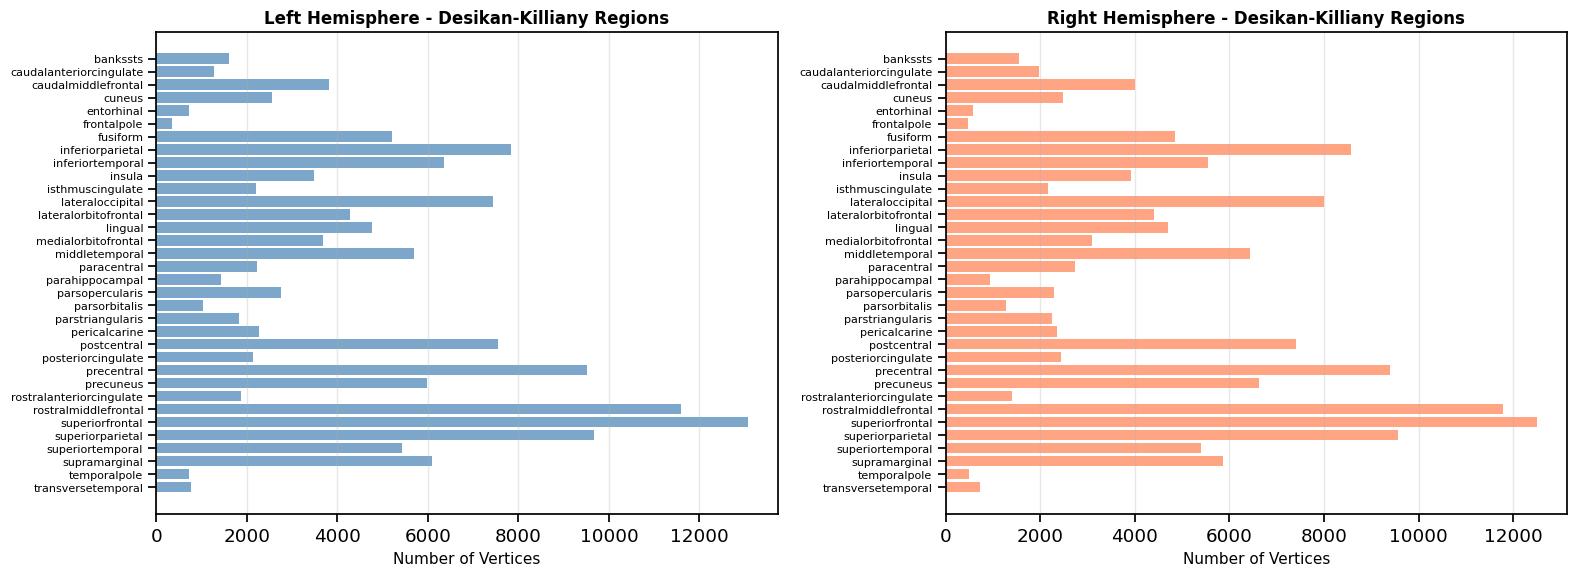

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left hemisphere
lh_names = [label.name.replace('-lh', '') for label in labels_lh]
lh_sizes = [len(label.vertices) for label in labels_lh]

axes[0].barh(range(len(lh_names)), lh_sizes, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(lh_names)))
axes[0].set_yticklabels(lh_names, fontsize=8)
axes[0].set_xlabel('Number of Vertices', fontsize=11)
axes[0].set_title('Left Hemisphere - Desikan-Killiany Regions', 
                  fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Right hemisphere
rh_names = [label.name.replace('-rh', '') for label in labels_rh]
rh_sizes = [len(label.vertices) for label in labels_rh]

axes[1].barh(range(len(rh_names)), rh_sizes, color='coral', alpha=0.7)
axes[1].set_yticks(range(len(rh_names)))
axes[1].set_yticklabels(rh_names, fontsize=8)
axes[1].set_xlabel('Number of Vertices', fontsize=11)
axes[1].set_title('Right Hemisphere - Desikan-Killiany Regions', 
                  fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 5. Extracting ROI Time Courses

For each ROI, we'll:
1. Compute source estimates
2. Find which sources belong to the ROI
3. Average their activity to get one time course per ROI

**Extraction methods:**
- **Mean**: Average all sources in the ROI (most common)
- **PCA**: First principal component (captures dominant pattern)
- **Max**: Maximum across sources (sensitive to outliers)

#### Compute Source Estimates for Epochs
Apply inverse solution to epochs (not averaged). This gives us source estimates for each individual trial.

In [12]:
snr = 3.0
lambda2 = 1.0 / snr ** 2
method = 'dSPM'

# Compute source estimates for auditory epochs
epochs_auditory = epochs['auditory']

stcs_epochs = apply_inverse_epochs(
    epochs_auditory,
    inverse_operator,
    lambda2,
    method=method,
    pick_ori=None,
    verbose=False
)

print(f"Computed source estimates for {len(stcs_epochs)} epochs")
print(f"Each source estimate has shape: {stcs_epochs[0].data.shape}")
print(f"  (sources × time points)")

Computed source estimates for 116 epochs
Each source estimate has shape: (7498, 421)
  (sources × time points)


In [13]:
# Function to extract label time courses from source estimates
def extract_label_time_courses(stcs, labels, mode='mean'):
    """
    Extract time courses from labels.
    """
    n_epochs = len(stcs)
    n_labels = len(labels)
    n_times = len(stcs[0].times)
    
    label_tc = np.zeros((n_epochs, n_labels, n_times))
    
    for epoch_idx, stc in enumerate(stcs):
        for label_idx, label in enumerate(labels):
            # Extract time course for this label
            tc = stc.extract_label_time_course(label, src, mode=mode)
            label_tc[epoch_idx, label_idx, :] = tc.flatten()
    
    return label_tc

In [14]:
# Extract time courses using mean mode
print("Extracting label time courses (this may take a minute)...")
label_tc = extract_label_time_courses(stcs_epochs, labels, mode='mean')

print(f"\nLabel time courses shape: {label_tc.shape}")
print(f"  (n_epochs={label_tc.shape[0]}, n_labels={label_tc.shape[1]}, n_times={label_tc.shape[2]})")

Extracting label time courses (this may take a minute)...
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode

In [15]:
# Average across epochs to get one time course per label
label_tc_avg = np.mean(label_tc, axis=0)

print(f"Averaged time courses shape: {label_tc_avg.shape}")
print(f"  (n_labels={label_tc_avg.shape[0]}, n_times={label_tc_avg.shape[1]})")

Averaged time courses shape: (68, 421)
  (n_labels=68, n_times=421)


In [16]:
# Get time vector
times = stcs_epochs[0].times

### 6. Analyzing Activity in Specific ROIs

Let's focus on regions we expect to be active during auditory stimulation:

**Primary auditory cortex regions:**
- **Superior temporal gyrus** (STG)
- **Transverse temporal gyrus** (Heschl's gyrus - primary auditory cortex)

**For comparison:**
- **Visual cortex** (should be less active)

In [17]:
# Find labels of interest
auditory_keywords = ['superiortemporal', 'transversetemporal']
visual_keywords = ['pericalcarine', 'lateraloccipital', 'lingual']

auditory_labels = []
visual_labels = []

for label in labels:
    label_name_lower = label.name.lower()
    
    # Check for auditory regions
    for keyword in auditory_keywords:
        if keyword in label_name_lower:
            auditory_labels.append(label)
            break
    
    # Check for visual regions
    for keyword in visual_keywords:
        if keyword in label_name_lower:
            visual_labels.append(label)
            break

print("Auditory regions found:")
for label in auditory_labels:
    print(f"  - {label.name}")

print("\nVisual regions found:")
for label in visual_labels:
    print(f"  - {label.name}")

Auditory regions found:
  - superiortemporal-lh
  - superiortemporal-rh
  - transversetemporal-lh
  - transversetemporal-rh

Visual regions found:
  - lateraloccipital-lh
  - lateraloccipital-rh
  - lingual-lh
  - lingual-rh
  - pericalcarine-lh
  - pericalcarine-rh


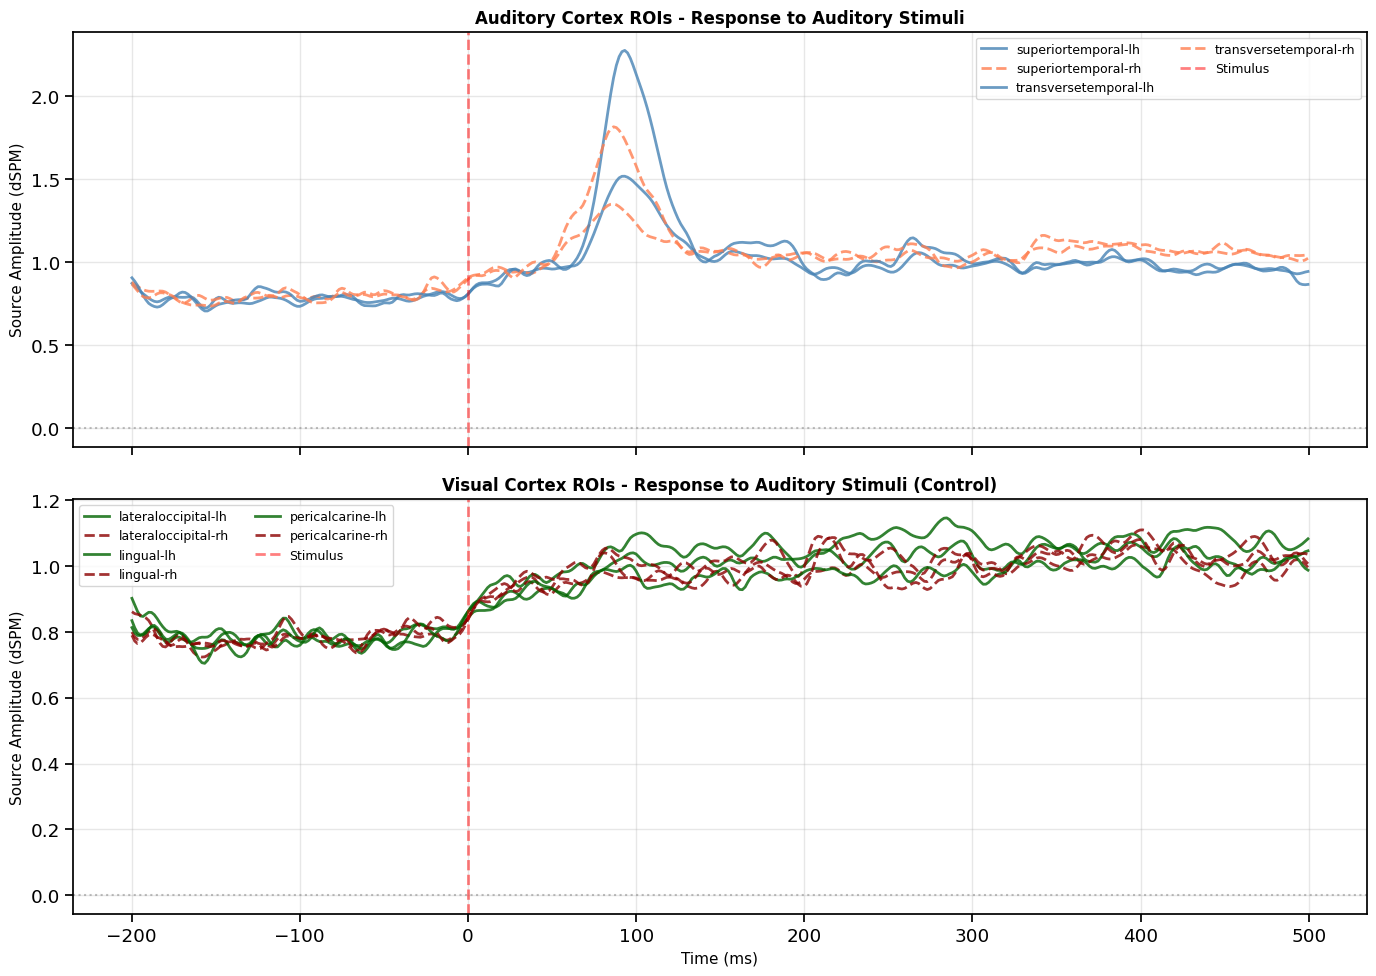

In [18]:
# Plot time courses for auditory and visual regions
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Auditory regions
ax = axes[0]
for label in auditory_labels:
    label_idx = labels.index(label)
    color = 'steelblue' if label.hemi == 'lh' else 'coral'
    linestyle = '-' if label.hemi == 'lh' else '--'
    
    ax.plot(times * 1000, label_tc_avg[label_idx, :],
            label=label.name, color=color, linestyle=linestyle,
            linewidth=2, alpha=0.8)

ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Stimulus')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('Source Amplitude (dSPM)', fontsize=11)
ax.set_title('Auditory Cortex ROIs - Response to Auditory Stimuli', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9, ncol=2)
ax.grid(alpha=0.3)

# Visual regions
ax = axes[1]
for label in visual_labels:
    label_idx = labels.index(label)
    color = 'darkgreen' if label.hemi == 'lh' else 'darkred'
    linestyle = '-' if label.hemi == 'lh' else '--'
    
    ax.plot(times * 1000, label_tc_avg[label_idx, :],
            label=label.name, color=color, linestyle=linestyle,
            linewidth=2, alpha=0.8)

ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Stimulus')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Source Amplitude (dSPM)', fontsize=11)
ax.set_title('Visual Cortex ROIs - Response to Auditory Stimuli (Control)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Comparing ROI Activity Across Conditions

Now let's compare how the same ROIs respond to different stimulus types:
- **Auditory stimuli** → Should activate auditory cortex
- **Visual stimuli** → Should activate visual cortex

This demonstrates the **selectivity** of brain regions.

In [19]:
# Compute source estimates for all conditions
conditions = ['auditory', 'visual']
label_tc_by_condition = {}

for condition in conditions:
    print(f"\nProcessing {condition} condition...")
    
    # Get epochs for this condition
    epochs_cond = epochs[condition]
    
    # Apply inverse
    stcs_cond = apply_inverse_epochs(
        epochs_cond,
        inverse_operator,
        lambda2,
        method=method,
        pick_ori=None,
        verbose=False
    )
    
    # Extract label time courses
    label_tc_cond = extract_label_time_courses(stcs_cond, labels, mode='mean')
    
    # Average across epochs
    label_tc_by_condition[condition] = np.mean(label_tc_cond, axis=0)
    
    print(f"  Extracted {label_tc_cond.shape[0]} epochs")

print("\nAll conditions processed")


Processing auditory condition...
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time 

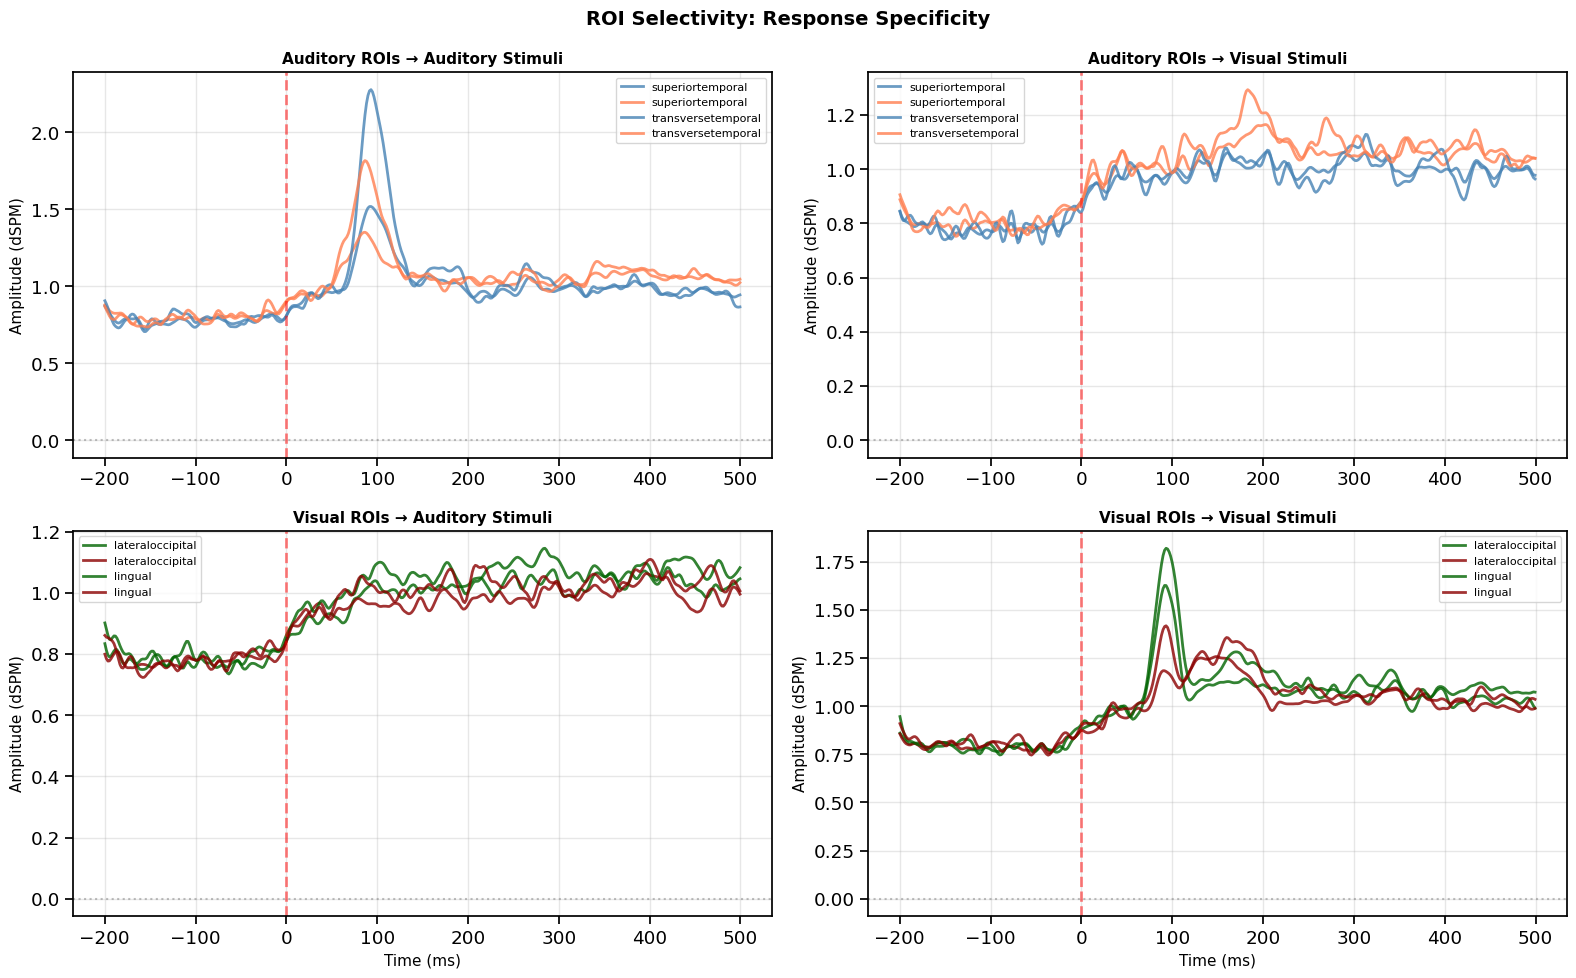

In [20]:
# Plot auditory and visual ROIs for both stimulus types
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top row: Auditory ROIs
# Left: response to auditory stimuli
ax = axes[0, 0]
for label in auditory_labels[:4]:  # Limit to 4 for clarity
    label_idx = labels.index(label)
    color = 'steelblue' if label.hemi == 'lh' else 'coral'
    ax.plot(times * 1000, label_tc_by_condition['auditory'][label_idx, :], label=label.name.split('-')[0], color=color, linewidth=2, alpha=0.8)

ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('Amplitude (dSPM)', fontsize=11)
ax.set_title('Auditory ROIs → Auditory Stimuli', fontsize=11, fontweight='bold')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3)

# Right: response to visual stimuli
ax = axes[0, 1]
for label in auditory_labels[:4]:
    label_idx = labels.index(label)
    color = 'steelblue' if label.hemi == 'lh' else 'coral'
    ax.plot(times * 1000, label_tc_by_condition['visual'][label_idx, :], label=label.name.split('-')[0], color=color, linewidth=2, alpha=0.8)

ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('Amplitude (dSPM)', fontsize=11)
ax.set_title('Auditory ROIs → Visual Stimuli', fontsize=11, fontweight='bold')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3)

# Bottom row: Visual ROIs
# Left: response to auditory stimuli
ax = axes[1, 0]
for label in visual_labels[:4]:  # Limit to 4 for clarity
    label_idx = labels.index(label)
    color = 'darkgreen' if label.hemi == 'lh' else 'darkred'
    ax.plot(times * 1000, label_tc_by_condition['auditory'][label_idx, :], label=label.name.split('-')[0], color=color, linewidth=2, alpha=0.8)

ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Amplitude (dSPM)', fontsize=11)
ax.set_title('Visual ROIs → Auditory Stimuli', fontsize=11, fontweight='bold')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3)

# Right: response to visual stimuli
ax = axes[1, 1]
for label in visual_labels[:4]:
    label_idx = labels.index(label)
    color = 'darkgreen' if label.hemi == 'lh' else 'darkred'
    ax.plot(times * 1000, label_tc_by_condition['visual'][label_idx, :], label=label.name.split('-')[0], color=color, linewidth=2, alpha=0.8)

ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Amplitude (dSPM)', fontsize=11)
ax.set_title('Visual ROIs → Visual Stimuli', fontsize=11, fontweight='bold')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('ROI Selectivity: Response Specificity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. Quantifying ROI Responses

Let's quantify the **peak amplitude** and **latency** for each ROI to compare them statistically.

**Metrics:**
- **Peak amplitude**: Maximum absolute value in a time window
- **Peak latency**: Time of maximum response
- **Mean amplitude**: Average activity in a time window

In [21]:
# Define analysis time window (0-300 ms post-stimulus)
time_window = (0.0, 0.3)
time_mask = (times >= time_window[0]) & (times <= time_window[1])

# Create summary dataframe
roi_metrics = []

for condition in ['auditory', 'visual']:
    for label in labels:
        label_idx = labels.index(label)
        tc = label_tc_by_condition[condition][label_idx, time_mask]
        
        # Compute metrics
        peak_amp = np.max(np.abs(tc))
        peak_idx = np.argmax(np.abs(tc))
        peak_lat = times[time_mask][peak_idx] * 1000  # Convert to ms
        mean_amp = np.mean(np.abs(tc))
        
        roi_metrics.append({
            'condition': condition,
            'roi': label.name.split('-')[0],
            'hemisphere': label.hemi,
            'peak_amplitude': peak_amp,
            'peak_latency': peak_lat,
            'mean_amplitude': mean_amp
        })

df_metrics = pd.DataFrame(roi_metrics)

print("ROI Metrics Summary:")
print(df_metrics.head(10))
print(f"\nTotal entries: {len(df_metrics)}")

ROI Metrics Summary:
  condition                      roi hemisphere  peak_amplitude  peak_latency  \
0  auditory                 bankssts         lh        1.795297     98.232646   
1  auditory                 bankssts         rh        1.245146     68.263364   
2  auditory  caudalanteriorcingulate         lh        1.104671    279.713298   
3  auditory  caudalanteriorcingulate         rh        1.161636    259.733777   
4  auditory      caudalmiddlefrontal         lh        1.011844    243.084176   
5  auditory      caudalmiddlefrontal         rh        1.087653    279.713298   
6  auditory                   cuneus         lh        1.010213    294.697939   
7  auditory                   cuneus         rh        1.028470    209.784974   
8  auditory               entorhinal         lh        1.098681     93.237766   
9  auditory               entorhinal         rh        1.230446    233.094415   

   mean_amplitude  
0        1.111760  
1        1.008965  
2        1.013693  
3      

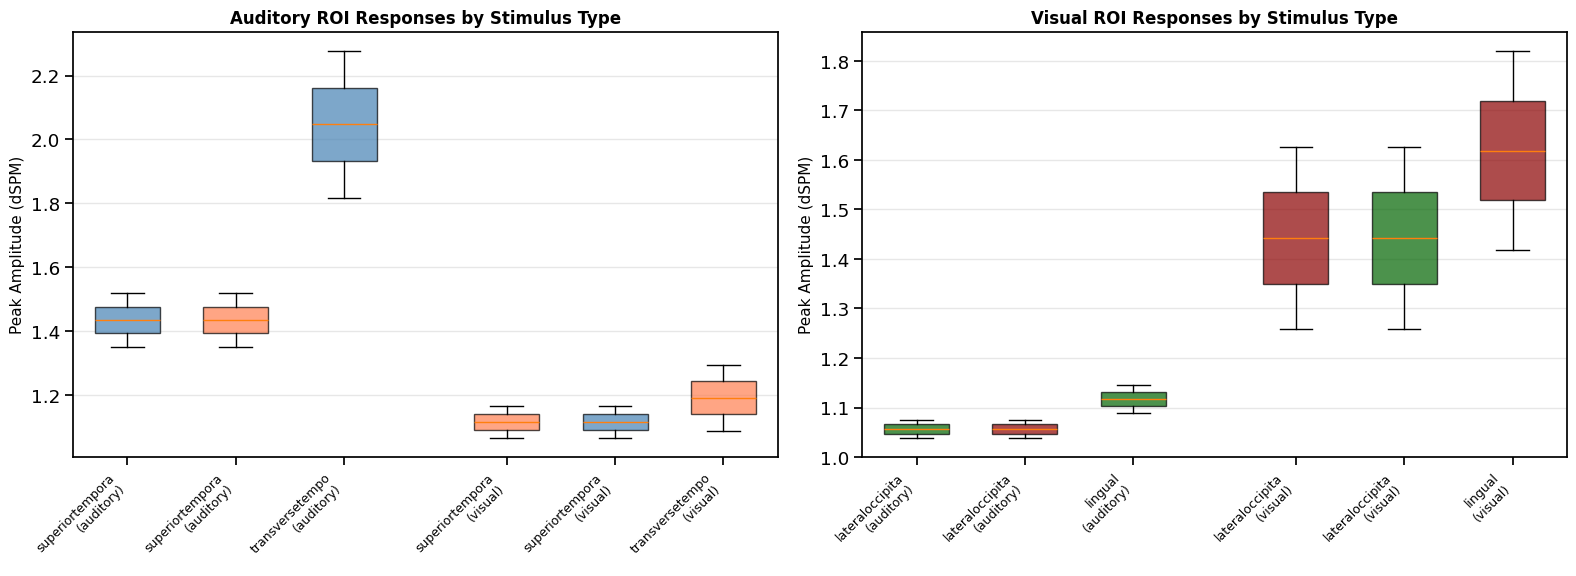

In [22]:
# Compare auditory and visual ROI responses

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get data for auditory ROIs
aud_roi_names = [label.name.split('-')[0] for label in auditory_labels]
df_aud = df_metrics[df_metrics['roi'].isin(aud_roi_names)]

# Peak amplitude comparison
ax = axes[0]
data_to_plot = []
labels_plot = []
positions = []
pos = 0

for condition in ['auditory', 'visual']:
    for roi in aud_roi_names[:3]:  # Top 3 auditory ROIs
        data = df_aud[(df_aud['condition'] == condition) & 
                      (df_aud['roi'] == roi)]['peak_amplitude'].values
        if len(data) > 0:
            data_to_plot.append(data)
            labels_plot.append(f"{roi[:15]}\n({condition})")
            positions.append(pos)
            pos += 1
    pos += 0.5  # Gap between conditions

bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True, showfliers=False)

# Color by condition
colors = ['steelblue', 'coral'] * len(aud_roi_names[:3])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(labels_plot, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Peak Amplitude (dSPM)', fontsize=11)
ax.set_title('Auditory ROI Responses by Stimulus Type', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Get data for visual ROIs
vis_roi_names = [label.name.split('-')[0] for label in visual_labels]
df_vis = df_metrics[df_metrics['roi'].isin(vis_roi_names)]

# Peak amplitude comparison
ax = axes[1]
data_to_plot = []
labels_plot = []
positions = []
pos = 0

for condition in ['auditory', 'visual']:
    for roi in vis_roi_names[:3]:  # Top 3 visual ROIs
        data = df_vis[(df_vis['condition'] == condition) & 
                      (df_vis['roi'] == roi)]['peak_amplitude'].values
        if len(data) > 0:
            data_to_plot.append(data)
            labels_plot.append(f"{roi[:15]}\n({condition})")
            positions.append(pos)
            pos += 1
    pos += 0.5

bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True, showfliers=False)

# Color by condition
colors = ['darkgreen', 'darkred'] * len(vis_roi_names[:3])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(labels_plot, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Peak Amplitude (dSPM)', fontsize=11)
ax.set_title('Visual ROI Responses by Stimulus Type', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 9. Functional Connectivity Between ROIs

**Functional connectivity** measures statistical dependencies between the activity of different brain regions.

**Common metrics:**
- **Correlation**: Pearson correlation between time courses
- **Coherence**: Frequency-specific correlation
- **Phase locking**: Consistency of phase relationships
- **Granger causality**: Directional influence

We'll compute:
1. **Correlation matrices** between ROI time courses
2. **Coherence** in specific frequency bands

In [23]:
# Compute correlation between all ROI time courses
# Using the auditory condition

label_tc_aud = label_tc_by_condition['auditory']

# Compute correlation matrix
n_labels = label_tc_aud.shape[0]
corr_matrix = np.corrcoef(label_tc_aud)

print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"  ({n_labels} ROIs × {n_labels} ROIs)")

Correlation matrix shape: (68, 68)
  (68 ROIs × 68 ROIs)


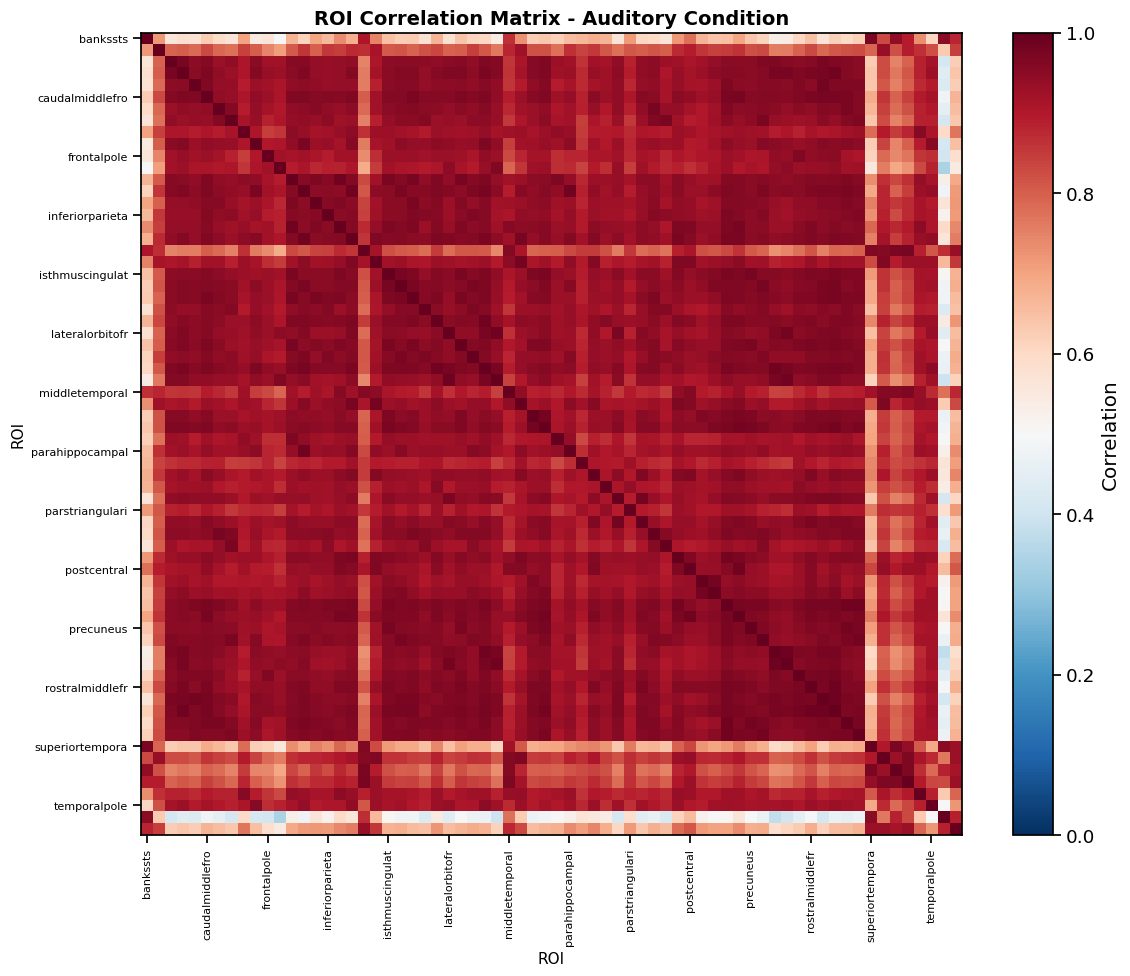

In [24]:
# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Correlation')

# Label axes with ROI names (every 5th label to avoid crowding)
tick_positions = range(0, n_labels, 5)
tick_labels = [labels[i].name.split('-')[0][:15] for i in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, fontsize=8)

ax.set_title('ROI Correlation Matrix - Auditory Condition', fontsize=14, fontweight='bold')
ax.set_xlabel('ROI', fontsize=11)
ax.set_ylabel('ROI', fontsize=11)

plt.tight_layout()
plt.show()

#### Focus on connectivity within auditory regions


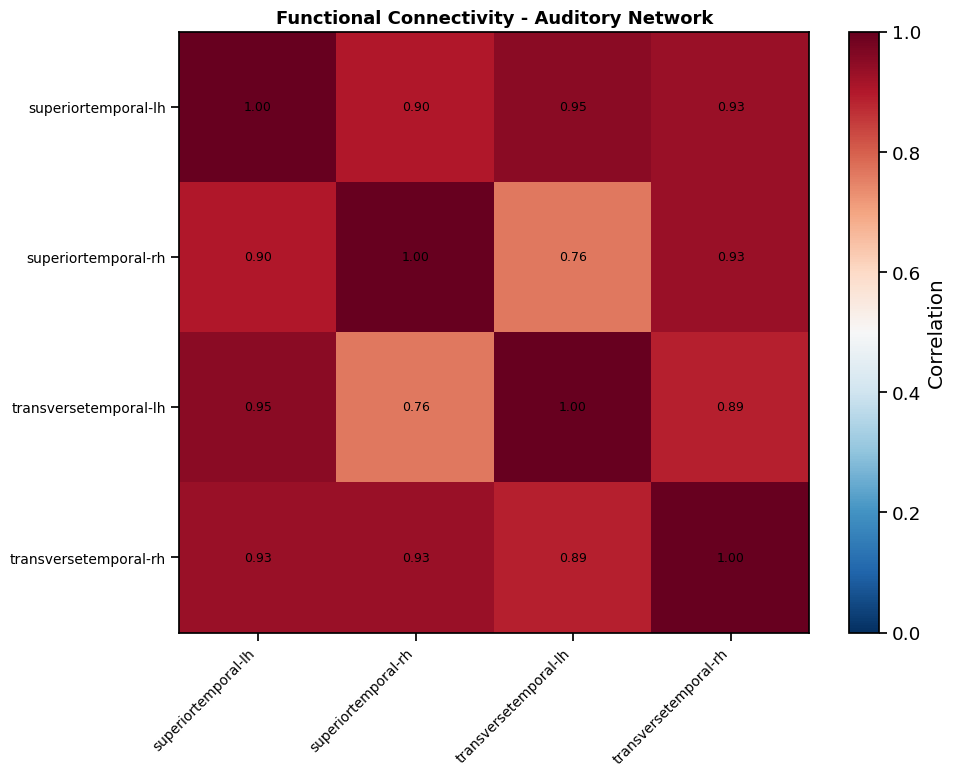

In [25]:
# Get indices of auditory ROIs
aud_indices = [labels.index(label) for label in auditory_labels]

# Extract sub-matrix for auditory regions
corr_aud = corr_matrix[np.ix_(aud_indices, aud_indices)]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_aud, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')

# Add values in cells
for i in range(len(aud_indices)):
    for j in range(len(aud_indices)):
        text = ax.text(j, i, f'{corr_aud[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=9)

cbar = plt.colorbar(im, ax=ax, label='Correlation')

# Label axes
aud_names = [label.name for label in auditory_labels]
ax.set_xticks(range(len(aud_indices)))
ax.set_xticklabels(aud_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(aud_indices)))
ax.set_yticklabels(aud_names, fontsize=10)

ax.set_title('Functional Connectivity - Auditory Network', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
print("\nStrong correlations within auditory network (|r| > 0.5):")
for i in range(len(aud_indices)):
    for j in range(i+1, len(aud_indices)):
        if abs(corr_aud[i, j]) > 0.5:
            print(f"  {aud_names[i]:40s} <--> {aud_names[j]:40s}: r = {corr_aud[i, j]:.3f}")


Strong correlations within auditory network (|r| > 0.5):
  superiortemporal-lh                      <--> superiortemporal-rh                     : r = 0.900
  superiortemporal-lh                      <--> transversetemporal-lh                   : r = 0.951
  superiortemporal-lh                      <--> transversetemporal-rh                   : r = 0.932
  superiortemporal-rh                      <--> transversetemporal-lh                   : r = 0.764
  superiortemporal-rh                      <--> transversetemporal-rh                   : r = 0.933
  transversetemporal-lh                    <--> transversetemporal-rh                   : r = 0.888


### 10. Seed-Based Connectivity Analysis

**Seed-based analysis** involves:
1. Select a "seed" ROI (region of interest)
2. Compute its correlation with all other ROIs
3. Visualize which regions are functionally connected to the seed

This is useful for mapping functional networks anchored around a specific region.

In [27]:
# Choose a seed region: left superior temporal gyrus (primary auditory cortex)
seed_label = None
for label in auditory_labels:
    if 'superiortemporal' in label.name.lower() and label.hemi == 'lh':
        seed_label = label
        break

if seed_label is None:
    # Fallback to first auditory label
    seed_label = auditory_labels[0]

seed_idx = labels.index(seed_label)
print(f"Seed ROI: {seed_label.name}")
print(f"Seed index: {seed_idx}")

Seed ROI: superiortemporal-lh
Seed index: 60


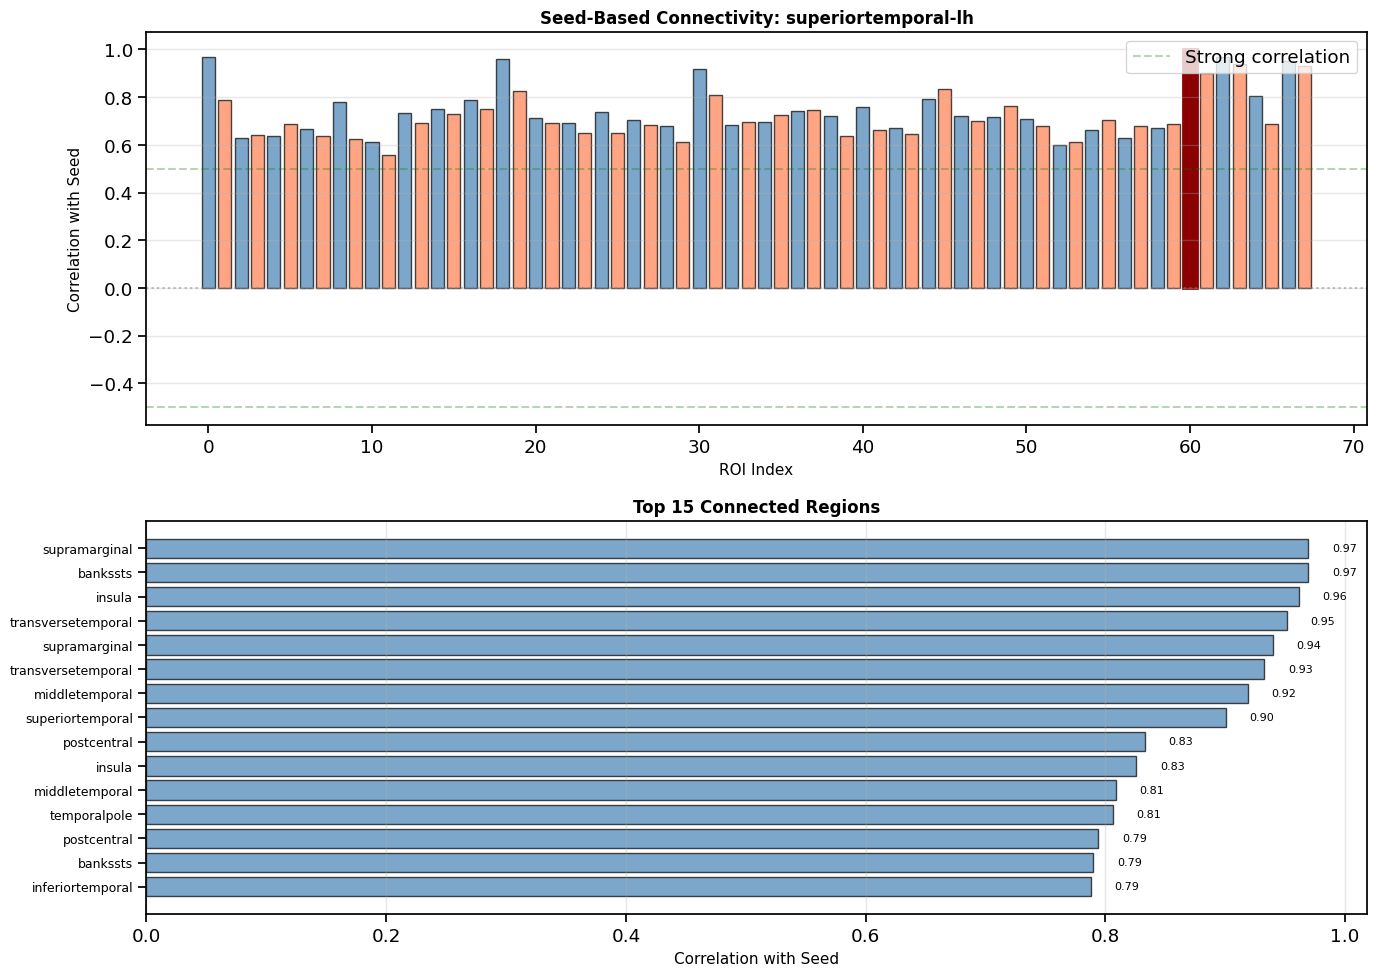

In [28]:
# Get correlations with all other ROIs
seed_connectivity = corr_matrix[seed_idx, :]

# Create a visualization showing connectivity strength
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top panel: Bar plot of connectivity
ax = axes[0]
colors = ['steelblue' if label.hemi == 'lh' else 'coral' for label in labels]
bars = ax.bar(range(len(labels)), seed_connectivity, color=colors, alpha=0.7, edgecolor='black')

# Highlight the seed
bars[seed_idx].set_color('darkred')
bars[seed_idx].set_alpha(1.0)
bars[seed_idx].set_linewidth(2)

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(0.5, color='green', linestyle='--', alpha=0.3, label='Strong correlation')
ax.axhline(-0.5, color='green', linestyle='--', alpha=0.3)
ax.set_xlabel('ROI Index', fontsize=11)
ax.set_ylabel('Correlation with Seed', fontsize=11)
ax.set_title(f'Seed-Based Connectivity: {seed_label.name}', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')

# Bottom panel: Show top connected regions
ax = axes[1]

# Sort by absolute correlation (excluding self)
connectivity_abs = np.abs(seed_connectivity)
connectivity_abs[seed_idx] = 0  # Exclude seed itself
top_n = 15
top_indices = np.argsort(connectivity_abs)[-top_n:][::-1]

top_names = [labels[i].name.split('-')[0][:25] for i in top_indices]
top_corrs = [seed_connectivity[i] for i in top_indices]
top_colors = ['steelblue' if seed_connectivity[i] > 0 else 'coral' for i in top_indices]

bars = ax.barh(range(len(top_names)), top_corrs, color=top_colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names, fontsize=9)
ax.set_xlabel('Correlation with Seed', fontsize=11)
ax.set_title(f'Top {top_n} Connected Regions', fontsize=12, fontweight='bold')
ax.axvline(0, color='gray', linestyle='-', alpha=0.5)
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()

# Add value labels
for i, (bar, corr) in enumerate(zip(bars, top_corrs)):
    ax.text(corr + 0.02 if corr > 0 else corr - 0.02, i, f'{corr:.2f}',
            va='center', ha='left' if corr > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

### 11. Coherence Analysis

**Coherence** measures frequency-specific correlation between signals. It tells us at which frequencies two ROIs are synchronized.

**Coherence formula:**
$$C_{xy}(f) = \frac{|S_{xy}(f)|^2}{S_{xx}(f) \cdot S_{yy}(f)}$$

Where:
- $S_{xy}(f)$ is the cross-spectral density
- $S_{xx}(f)$ and $S_{yy}(f)$ are the power spectral densities

**Range:** 0 (no coherence) to 1 (perfect coherence)

In [29]:
# Compute coherence between seed and top connected regions
from scipy.signal import coherence

# Select a few ROI pairs to analyze
roi_pairs = [
    (seed_idx, top_indices[0]),
    (seed_idx, top_indices[1]),
    (seed_idx, top_indices[2])
]

# Sampling frequency
sfreq = 1.0 / (times[1] - times[0])

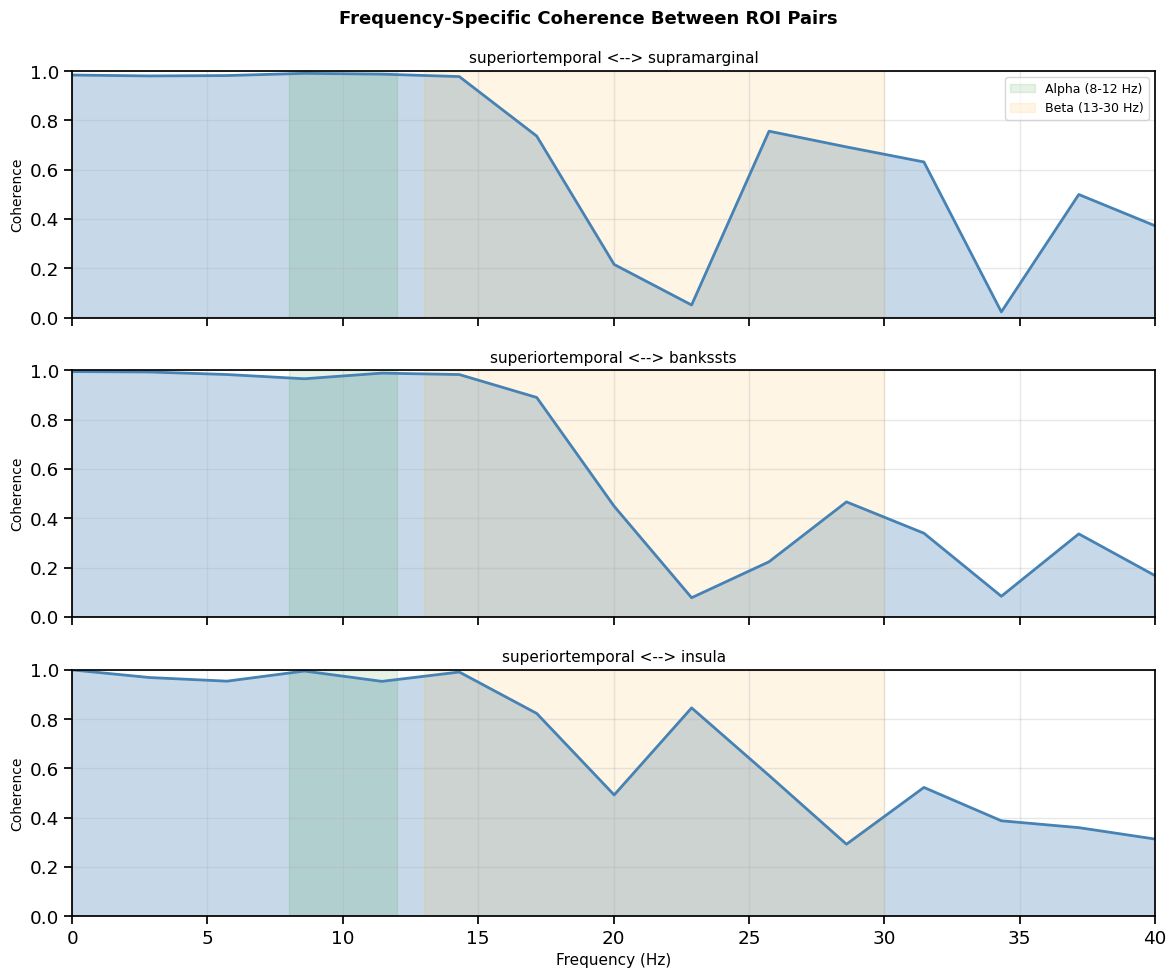

In [30]:
fig, axes = plt.subplots(len(roi_pairs), 1, figsize=(12, 10), sharex=True)

for idx, (roi1_idx, roi2_idx) in enumerate(roi_pairs):
    # Get time courses
    tc1 = label_tc_aud[roi1_idx, :]
    tc2 = label_tc_aud[roi2_idx, :]
    
    # Compute coherence
    freqs, Cxy = coherence(tc1, tc2, fs=sfreq, nperseg=len(tc1)//2)
    
    ax = axes[idx] if len(roi_pairs) > 1 else axes
    ax.plot(freqs, Cxy, linewidth=2, color='steelblue')
    ax.fill_between(freqs, 0, Cxy, alpha=0.3, color='steelblue')
    
    ax.axvspan(8, 12, alpha=0.1, color='green', label='Alpha (8-12 Hz)')
    ax.axvspan(13, 30, alpha=0.1, color='orange', label='Beta (13-30 Hz)')
    
    ax.set_ylabel('Coherence', fontsize=10)
    ax.set_title(f'{labels[roi1_idx].name.split("-")[0]} <--> {labels[roi2_idx].name.split("-")[0]}', fontsize=11)
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_xlim([0, 40])

plt.suptitle('Frequency-Specific Coherence Between ROI Pairs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 12. Network Hub Analysis

**Network hubs** are ROIs that are highly connected to many other regions. They play important roles in integrating information across the brain.

**Metrics:**
- **Degree**: Number of connections
- **Betweenness centrality**: How often a node lies on shortest paths
- **Clustering coefficient**: How connected a node's neighbors are

In [31]:
import networkx as nx

threshold = 0.90

# Create graph
G = nx.Graph()

# Add nodes (all ROIs)
for i, label in enumerate(labels):
    G.add_node(i, name=label.name.split('-')[0], hemi=label.hemi)

# Add edges for strong correlations
edges_added = 0
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        if abs(corr_matrix[i, j]) > threshold:
            G.add_edge(i, j, weight=abs(corr_matrix[i, j]))
            edges_added += 1

print(f"Network statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()} (threshold = {threshold})")
print(f"  Connected components: {nx.number_connected_components(G)}")

Network statistics:
  Nodes: 68
  Edges: 1540 (threshold = 0.9)
  Connected components: 1


In [32]:
# Find largest connected component
if nx.number_connected_components(G) > 0:
    largest_cc = max(nx.connected_components(G), key=len)
    G_largest = G.subgraph(largest_cc).copy()
    print(f"Largest component: {G_largest.number_of_nodes()} nodes")
else:
    G_largest = 0
    print("The graph has no connected components.")

Largest component: 68 nodes


Top 10 Hub Regions (by degree):
                 roi hemisphere  degree  betweenness  clustering
          precentral         rh      59     0.012589    0.845120
         postcentral         lh      59     0.021224    0.828755
    inferiortemporal         rh      59     0.012589    0.845120
          precentral         lh      58     0.006438    0.869328
lateralorbitofrontal         lh      58     0.006438    0.869328
    inferiortemporal         lh      57     0.009350    0.877820
             lingual         lh      57     0.004572    0.892857
    isthmuscingulate         lh      57     0.004572    0.892857
rostralmiddlefrontal         rh      57     0.003764    0.890351
           precuneus         lh      56     0.001998    0.914935


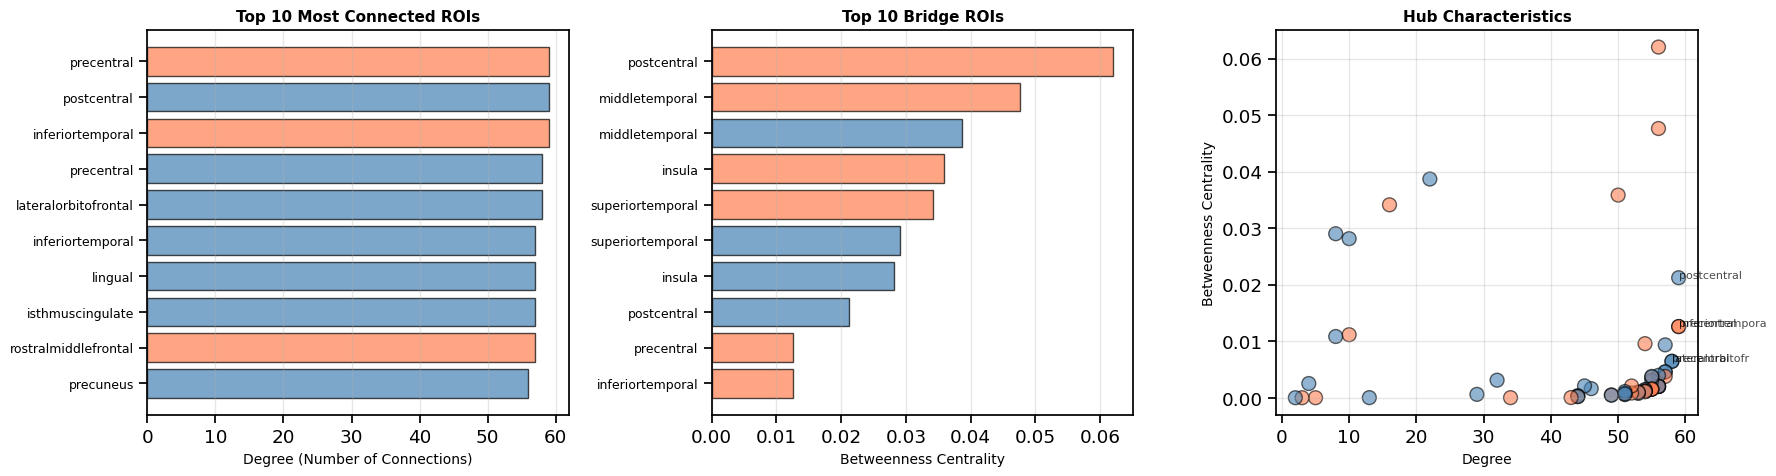

In [33]:
if G_largest.number_of_nodes() > 0:
    # Compute network metrics
    degree = dict(G_largest.degree())
    betweenness = nx.betweenness_centrality(G_largest)
    clustering = nx.clustering(G_largest)
    
    # Create dataframe
    network_metrics = []
    for node in G_largest.nodes():
        network_metrics.append({
            'roi': labels[node].name.split('-')[0],
            'hemisphere': labels[node].hemi,
            'degree': degree[node],
            'betweenness': betweenness[node],
            'clustering': clustering[node]
        })
    
    df_network = pd.DataFrame(network_metrics)
    df_network = df_network.sort_values('degree', ascending=False)
    
    print("Top 10 Hub Regions (by degree):")
    print(df_network.head(10).to_string(index=False))
    
    # Visualize hub metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Degree distribution
    ax = axes[0]
    top_10 = df_network.head(10)
    colors = ['steelblue' if h == 'lh' else 'coral' for h in top_10['hemisphere']]
    bars = ax.barh(range(len(top_10)), top_10['degree'], color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(top_10['roi'], fontsize=9)
    ax.set_xlabel('Degree (Number of Connections)', fontsize=10)
    ax.set_title('Top 10 Most Connected ROIs', fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    
    # Betweenness centrality
    ax = axes[1]
    top_10_between = df_network.sort_values('betweenness', ascending=False).head(10)
    colors = ['steelblue' if h == 'lh' else 'coral' for h in top_10_between['hemisphere']]
    bars = ax.barh(range(len(top_10_between)), top_10_between['betweenness'], color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(top_10_between)))
    ax.set_yticklabels(top_10_between['roi'], fontsize=9)
    ax.set_xlabel('Betweenness Centrality', fontsize=10)
    ax.set_title('Top 10 Bridge ROIs', fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    
    # Degree vs Betweenness scatter
    ax = axes[2]
    colors_scatter = ['steelblue' if h == 'lh' else 'coral' for h in df_network['hemisphere']]
    ax.scatter(df_network['degree'], df_network['betweenness'], c=colors_scatter, s=100, alpha=0.6, edgecolor='black')
    
    # Label top hubs
    for idx in range(min(5, len(df_network))):
        row = df_network.iloc[idx]
        ax.annotate(row['roi'][:15], (row['degree'], row['betweenness']), fontsize=8, alpha=0.7)
    
    ax.set_xlabel('Degree', fontsize=10)
    ax.set_ylabel('Betweenness Centrality', fontsize=10)
    ax.set_title('Hub Characteristics', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 13. Condition-Specific Networks

Let's compare how functional connectivity differs between auditory and visual stimulation.

**Questions:**
- Do auditory stimuli create stronger connectivity in auditory regions?
- Do visual stimuli create stronger connectivity in visual regions?
- Are there condition-specific network changes?

In [34]:
# Compute correlation matrices for both conditions
corr_auditory = np.corrcoef(label_tc_by_condition['auditory'])
corr_visual = np.corrcoef(label_tc_by_condition['visual'])

# Compute difference
corr_diff = corr_auditory - corr_visual

# Focus on auditory ROIs
aud_indices = [labels.index(label) for label in auditory_labels]

# Extract sub-matrices
corr_aud_sub = corr_auditory[np.ix_(aud_indices, aud_indices)]
corr_vis_sub = corr_visual[np.ix_(aud_indices, aud_indices)]
corr_diff_sub = corr_diff[np.ix_(aud_indices, aud_indices)]

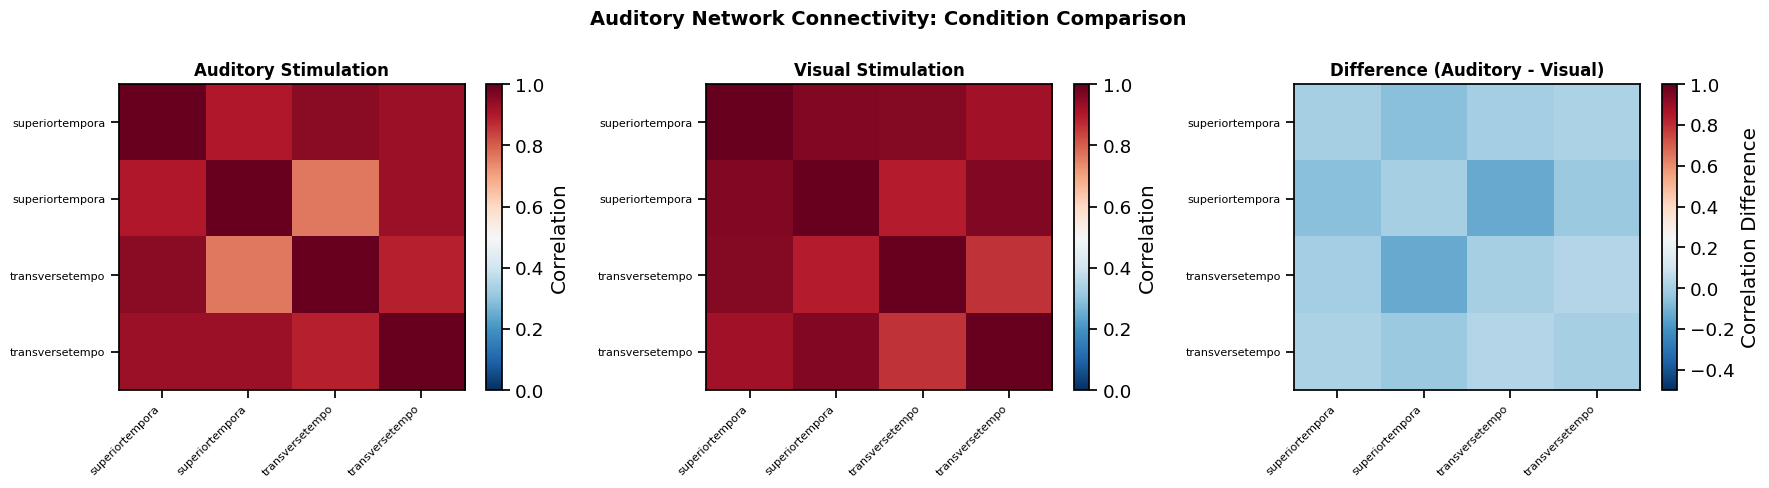

In [35]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Auditory condition
ax = axes[0]
im = ax.imshow(corr_aud_sub, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')
ax.set_title('Auditory Stimulation', fontsize=12, fontweight='bold')
aud_names = [label.name.split('-')[0][:15] for label in auditory_labels]
ax.set_xticks(range(len(aud_indices)))
ax.set_xticklabels(aud_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(aud_indices)))
ax.set_yticklabels(aud_names, fontsize=8)
plt.colorbar(im, ax=ax, label='Correlation')

# Visual condition
ax = axes[1]
im = ax.imshow(corr_vis_sub, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')
ax.set_title('Visual Stimulation', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(aud_indices)))
ax.set_xticklabels(aud_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(aud_indices)))
ax.set_yticklabels(aud_names, fontsize=8)
plt.colorbar(im, ax=ax, label='Correlation')

# Difference
ax = axes[2]
im = ax.imshow(corr_diff_sub, cmap='RdBu_r', vmin=-0.5, vmax=1, aspect='auto')
ax.set_title('Difference (Auditory - Visual)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(aud_indices)))
ax.set_xticklabels(aud_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(aud_indices)))
ax.set_yticklabels(aud_names, fontsize=8)
plt.colorbar(im, ax=ax, label='Correlation Difference')

plt.suptitle('Auditory Network Connectivity: Condition Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
print("\nNetwork Strength Comparison:")
print(f"Auditory condition - Mean |correlation|: {np.mean(np.abs(corr_aud_sub)):.3f}")
print(f"Visual condition - Mean |correlation|: {np.mean(np.abs(corr_vis_sub)):.3f}")
print(f"Difference: {np.mean(np.abs(corr_aud_sub)) - np.mean(np.abs(corr_vis_sub)):.3f}")


Network Strength Comparison:
Auditory condition - Mean |correlation|: 0.921
Visual condition - Mean |correlation|: 0.945
Difference: -0.023


## Summary and Key Takeaways

### What We Learned

1. **ROI-Based Analysis:**
   - Reduces dimensionality from thousands of sources to dozens of regions
   - Provides anatomically interpretable results
   - Facilitates statistical comparisons and group studies
   - Trade-off: lose spatial detail but gain statistical power

2. **Brain Parcellation:**
   - Different atlases serve different purposes
   - Desikan-Killiany (68 regions): Standard anatomical parcellation
   - ROI definition affects results - be consistent!

3. **Extracting ROI Time Courses:**
   - **Mean**: Most common, averages all sources in ROI
   - **PCA**: Captures dominant pattern
   - **Max**: Can be sensitive to outliers
   - Choice depends on research question

4. **Functional Selectivity:**
   - Auditory cortex responds strongly to auditory stimuli
   - Visual cortex responds strongly to visual stimuli
   - This selectivity validates our source localization
   - Can quantify with peak amplitude, latency, mean activity

5. **Functional Connectivity:**
   - **Correlation matrices**: Show all pairwise relationships
   - **Seed-based analysis**: Map connectivity of specific regions
   - **Coherence**: Frequency-specific connectivity
   - **Network graphs**: Visualize connectivity structure

6. **Network Analysis:**
   - **Hub regions**: Highly connected nodes integrating information
   - **Degree**: Number of connections
   - **Betweenness**: Importance for network communication
   - **Condition-specific networks**: Connectivity varies with task

### Further Reading

**Key Papers:**
- Desikan et al. (2006) - Desikan-Killiany atlas
- Schaefer et al. (2018) - Functional parcellation
- Rubinov & Sporns (2010) - Complex network measures

**Documentation:**
- [MNE Label Tutorial](https://mne.tools/stable/auto_tutorials/forward/30_forward.html)
- [FreeSurfer Parcellation Guide](https://surfer.nmr.mgh.harvard.edu/fswiki/CorticalParcellation)